# Zero-Shot Energy Forecasting - Complete Thesis Analysis Visualization

## Thesis proposal
Proposed title: Temporal Granularity and Forecast Configuration for Zero-Shot Energy Forecasting: A Scenario-Oriented Evaluation of Time-Series Foundation Models

### Main research question:
Under which combinations of temporal granularity, historical context length and forecast horizon do pretrained time-series foundation models produce accurate and practically suitable zero-shot forecasts for electricity demand, solar and wind generation, and to what extent can differences in performance be explained by measurable characteristics of the series?

**Temporal Granularity and Forecast Configuration for Zero-Shot Energy Forecasting:
A Scenario-Oriented Evaluation of Time-Series Foundation Models**

**Author:** Aksha Makarani - GH1038937 (M.Sc. AI & Data Science)

---

This **single notebook** reproduces the entire empirical study end to end -> EDA -> methodology ->
every Stage configuration → each research question and hypothesis -> the methodological errors and
corrections. 

### Research questions
| RQ | question |
|---|---|
| **RQ1 - Temporal granularity** | How does zero-shot forecasting accuracy vary across temporal granularities for electricity demand, solar and wind when the underlying physical signals are held constant through controlled resampling? |
| **RQ2 - Forecast configuration** | How do historical context length and forecast horizon, expressed as both observation counts and real-world temporal duration, affect zero-shot forecasting accuracy, and how do these effects interact with temporal granularity? |
| **RQ3 - Scenario-oriented model selection** | Which model–granularity–context–horizon combinations provide the most favourable accuracy–inference-cost trade-off for representative energy forecasting scenarios? |
| **RQ4  - Explaining performance and failure** | To what extent can differences in zero-shot forecasting performance, including poor-performing configurations, be explained by measurable characteristics of the series, such as zero-inflation, volatility and seasonal structure? |

### Contents
0. Setup 1. Methodology 2. Pipeline map 3. Step-1 EDA 4. Data integrity 5. Stage-2 baseline
6. RQ1 granularity (3D) + feasibility 7. RQ2a context (3B) 8. RQ2b horizon (3C)
9. RQ2c interaction (3H, 3I) 10. Significance (3E) 11. RQ3 cost & deployability (3J, 3F)
12. Model comparison 13. RQ4 transfer (3G) 14. Benchmark robustness (3K) 15. H4 zero-inflation
16. Moirai patch (3L) 17. Errors & corrections 18. Hypothesis verdicts 19. Conclusions

## 0 - Setup

In [1]:
import os, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%matplotlib inline
# Charts are generated by the code below and rendered INLINE as each cell's output.
# No image files are written by default. Set SAVE_FIGS=True to ALSO export PNG/PDF.
SAVE_FIGS = False
FIGDIR = "figures_thesis"

# Okabe-Ito colourblind-safe palette (consistent across every figure)
GRAN_C  = {'native':'#0072B2', '1h':'#E69F00', '1D':'#009E73'}   # CSV 'gran' keys
GLAB    = {'native':'native', '1h':'hourly', '1D':'daily'}
GORD    = ['native','1h','1D']
MODEL_C = {'chronos':'#0072B2', 'timesfm':'#D55E00', 'moirai':'#009E73'}
MORD    = ['chronos','timesfm','moirai']
MNAME   = {'chronos':'Chronos','timesfm':'TimesFM','moirai':'Moirai'}
ET      = ['load','solar','wind']
ETN     = {'load':'Electricity demand','solar':'Solar','wind':'Wind'}
INK, MUTED = '#222222', '#8a94a3'

mpl.rcParams.update({
    'figure.dpi':120, 'savefig.dpi':300, 'savefig.bbox':'tight',
    'font.size':11.5, 'font.family':'DejaVu Sans',
    'axes.spines.top':False, 'axes.spines.right':False,
    'axes.grid':True, 'axes.axisbelow':True, 'grid.color':'#E8EBF0', 'grid.linewidth':0.8,
    'axes.edgecolor':'#666', 'axes.linewidth':0.9,
    'xtick.color':'#444','ytick.color':'#444','axes.labelcolor':INK,'text.color':INK,
    'legend.frameon':False,
})

def load(f):
    if not os.path.exists(f): print("  ! missing:", f); return None
    return pd.read_csv(f)
def clean(d): return d[~d.degenerate].dropna(subset=['relMAE']) if d is not None else None
def save(fig, stem):
    # Inline rendering happens via plt.show() in each cell. Only export files if asked.
    if SAVE_FIGS:
        os.makedirs(FIGDIR, exist_ok=True)
        fig.savefig(f"{FIGDIR}/{stem}.png"); fig.savefig(f"{FIGDIR}/{stem}.pdf")
        print(f"   exported {FIGDIR}/{stem}.png (+ .pdf, 300 DPI)")
def gran_legend(fig, y=-0.02):
    h=[Line2D([0],[0],color=GRAN_C[g],lw=2.6,marker='o',ms=6,label=GLAB[g]) for g in GORD]
    fig.legend(handles=h, loc='lower center', ncol=3, bbox_to_anchor=(0.5,y), fontsize=10.5)
def label_bars(ax, fmt="{:.0f}", zero_tag="0%", dy=0.01):
    ymax=ax.get_ylim()[1]
    for p in ax.patches:
        h=p.get_height()
        txt=zero_tag if h==0 else fmt.format(h)
        ax.text(p.get_x()+p.get_width()/2, h+ymax*dy, txt, ha='center', va='bottom',
                fontsize=8.5, color=INK)
print("Setup ready. Reading from:", os.getcwd())

Setup ready. Reading from: e:\Thesis\EnergyForcastModel


## 1. Methodology data, models, metric, design

### Datasets - Monash Time Series Forecasting Archive (`Monash-University/monash_tsf`)
| energy type | Monash config | native step | # series | native length |
|---|---|---|---|---|
| load  | `australian_electricity_demand` | 30 min | 5 | 230,736–232,272 |
| solar | `solar_10_minutes`              | 10 min | 5 | 52,560 |
| wind  | `wind_farms_minutely`           | 1 min  | 5 | 434,876 |

**5 series/type**, fixed **seed 7** (identical series in every stage). Granularities **native / hourly
/ daily** are produced by **resampling the native series** (mean) - controlled resampling makes
temporal granularity a genuine treatment rather than a change of data source. Panel cached to
`refined_panel_cache.pkl`.

### Models — three pretrained foundation models, used zero-shot (no fine-tuning)
| model | HF repo | ~params | median cost/forecast |
|---|---|---|---|
| Chronos-Bolt-Small | `amazon/chronos-bolt-small` | ~48 M | 0.017 s |
| TimesFM-2.5-200M | `google/timesfm-2.5-200m-pytorch` | 200 M | ~0.28 s (~16×) |
| Moirai-1.1-R-Small | `Salesforce/moirai-1.1-R-small` | ~14 M | 0.032 s |

Capacity is confounded with identity (all small variants) - a stated limitation.

### Primary metric - relMAE
**relMAE = forecast MAE ÷ MAE of a horizon-matched seasonal-naive benchmark at the same origin.**
Below 1.0 = beats the naive forecast it would replace. Period `m` = 48/144/1440 native, 24 hourly,
7 daily; `m = 1` is the random-walk benchmark (§14).

### Evaluation design & verified invariants
- **Rolling-origin with anchored origins** - every context length within a cell forecasts identical
  target windows (0 violations).
- **Fixed per-cell MASE scale** on a reserved segment, reused everywhere (0 violations).
- **Planned window counts** - `windows_for()` = max(≥30 windows, ≥14 days evaluated), capped;
  replaces a fixed *count*, which under-powers high-frequency cells (§17).
- **Degenerate-window filter** - constant-target windows (e.g. night-time solar zeros) flagged and
  excluded from headline tables (kept in the CSVs).
- **Integrity:** ~118k scored forecasts, 0 runtime errors, 0 NaN, 0 synthetic values, 12 notebooks.

## 2. Pipeline map every stage and its output
| stage / notebook | serves | output CSV |
|---|---|---|
| Step-1 EDA + `refined_stage3a` | data characteristics | `refined_stage3a_characteristics.csv` |
| `refined_stage2_baseline` | fixed-context baseline | `refined_stage2_results.csv` |
| `refined_stage3b_context_sweep` | RQ2 context | `refined_stage3b_context_sweep.csv` |
| `refined_stage3c_horizon_sweep` | RQ2 horizon | `refined_stage3c_horizon_sweep.csv` |
| `refined_stage3d_fixed_lead_time` | **RQ1** de-confounded | `..._fixed_lead_time.csv`, `..._feasibility.csv` |
| `refined_stage3e_significance` | Wilcoxon + Holm | `..._model_significance.csv`, `..._context_significance_holm.csv` |
| `refined_stage3f_selection_matrix` | RQ3 deployability | `..._selection_matrix.csv`, `..._all_configurations.csv` |
| `refined_stage3g_rq4_validation` | **RQ4** transfer | `..._leave_one_type_out.csv` |
| `refined_stage3h_context_horizon_cross` | RQ2 interaction (native) | `..._interaction_test.csv` |
| `refined_stage3i_granularity_interaction` | RQ2 × granularity | `..._granularity_interaction.csv` |
| `refined_stage3j_cost_tradeoff` | **RQ3** cost | `..._configurations_with_cost.csv`, `..._scenario_matrix.csv` |
| `refined_stage3k_benchmark_robustness` | robustness | `..._benchmark_comparison.csv` |
| `refined_stage3l_moirai_patch` | fairness | `..._model_board.csv` |

## 3. Step 1 - Exploratory data characteristics

Before forecasting: what do the signals look like? These measured properties (Stage 3A) are what RQ4
later uses to *predict* forecastability. Data quality is clean (0 missing, 0 duplicate timestamps
across all 15 series). The decisive property is **zero-inflation**.

Zero-inflation is summarised by the **median across series** (matching Stage 3A), which is robust to a
single idle wind farm (~80 % zeros). *Note:* one wind farm is flat across its native reference segment
and has no defined native MASE scale, so **wind statistics at native resolution are over 4 series**
(5 at hourly and daily); this is disclosed rather than hidden.

*Suggested caption - Fig EDA-1:* "Median exact-zero fraction by energy type and temporal granularity.
Electricity demand is never zero; solar is ~55 % zeros at native (night) falling to 0 % at daily; wind
remains zero-inflated at every resolution."

Native-resolution data profile (median over series):

       n_series  pct_zero_native  volatility_cv  seasonal_strength
etype                                                             
load          5            0.000          0.203              0.883
solar         5           55.289          1.475              0.843
wind          4           22.532          1.466              0.574

Note: wind has 4 usable series at native (one idle farm has no defined native scale); 5 at hourly/daily.



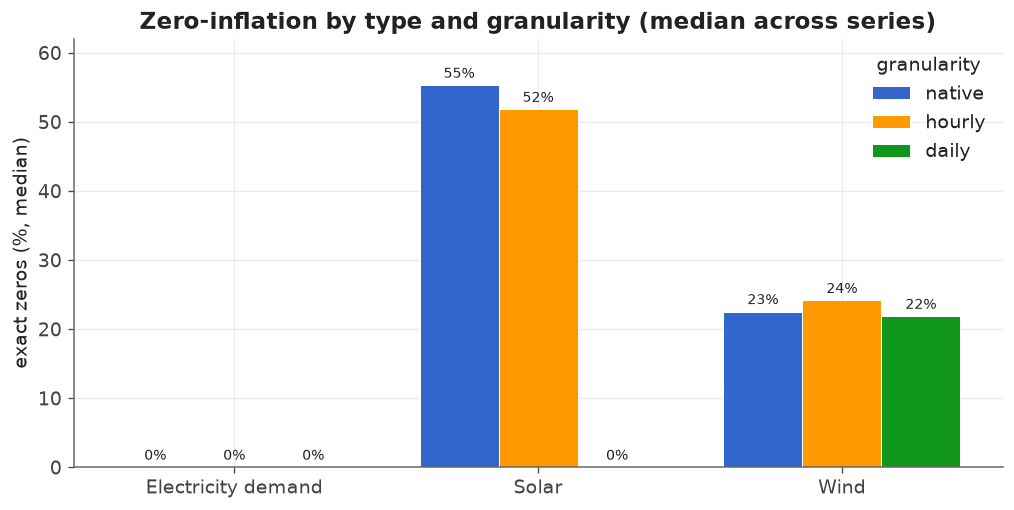

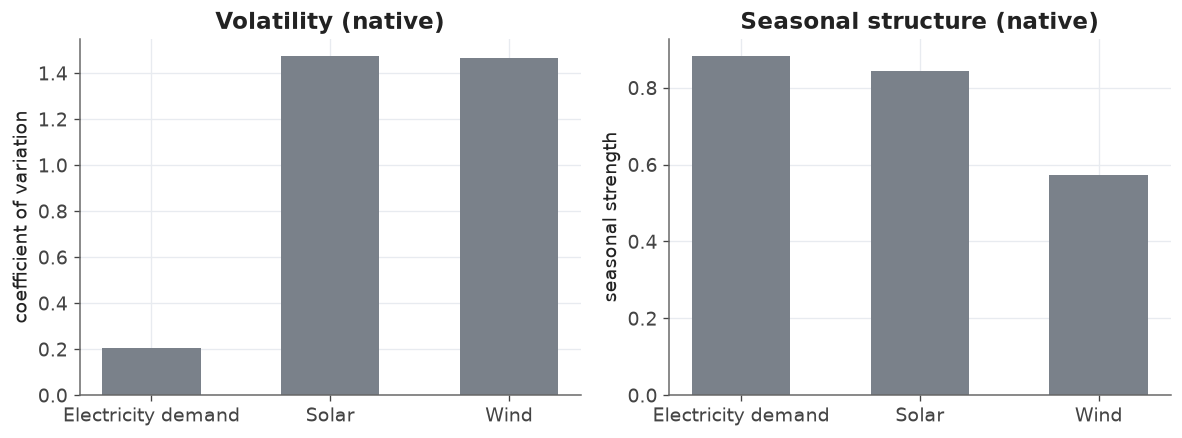

In [2]:
a = load("refined_stage3a_characteristics.csv")
prof = (a[a.gran=='native'].groupby('etype')
        .agg(n_series=('series_id','nunique'), pct_zero_native=('pct_zero','median'),
             volatility_cv=('cv','median'), seasonal_strength=('seasonal_strength','median')).round(3))
print("Native-resolution data profile (median over series):\n"); print(prof.to_string())
print(f"\nNote: wind has {a[(a.etype=='wind')&(a.gran=='native')].series_id.nunique()} usable series at "
      f"native (one idle farm has no defined native scale); 5 at hourly/daily.\n")

z = a.groupby(['etype','gran']).pct_zero.median().unstack()[GORD]   # MEDIAN, matches Stage 3A
x = np.arange(3); w = 0.26
fig, ax = plt.subplots(figsize=(8.6,4.4))
GRAN_C = dict(zip(GORD, ['#3366CC', '#FF9900', '#109618', '#DC3912']))
for i,g in enumerate(GORD):
    ax.bar(x+(i-1)*w, [z.loc[e,g] for e in ET], w, color=GRAN_C[g], label=GLAB[g],
           edgecolor='white', linewidth=0.6)
label_bars(ax, fmt="{:.0f}%")
ax.set_xticks(x); ax.set_xticklabels([ETN[e] for e in ET]); ax.set_ylabel('exact zeros (%, median)')
ax.set_ylim(0, 62); ax.set_title('Zero-inflation by type and granularity (median across series)', fontweight='bold')
ax.legend(title='granularity'); plt.tight_layout(); save(fig,'eda1_zero_inflation'); plt.show()

# volatility & seasonal strength
fig, (a1,a2) = plt.subplots(1,2,figsize=(10,3.8))
a1.bar([ETN[e] for e in ET], [prof.loc[e,'volatility_cv'] for e in ET], color="#7A818A", width=0.55)
a1.set_ylabel('coefficient of variation'); a1.set_title('Volatility (native)', fontweight='bold')
a2.bar([ETN[e] for e in ET], [prof.loc[e,'seasonal_strength'] for e in ET], color="#7A818A", width=0.55)
a2.set_ylabel('seasonal strength'); a2.set_title('Seasonal structure (native)', fontweight='bold')
plt.tight_layout(); save(fig,'eda2_volatility_seasonality'); plt.show()

## 4. Data integrity - every result rests on real, error-free runs

In [3]:
parts=[clean(load(f)) for f in ["refined_stage3b_context_sweep.csv","refined_stage3c_horizon_sweep.csv",
                                "refined_stage3d_fixed_lead_time.csv"]]
allr=pd.concat([p for p in parts if p is not None], ignore_index=True)
raw =pd.concat([load(f) for f in ["refined_stage3b_context_sweep.csv","refined_stage3c_horizon_sweep.csv",
                                  "refined_stage3d_fixed_lead_time.csv"]], ignore_index=True)
print(f"Scored forecast rows (3B+3C+3D): {len(raw):,}")
print(f"Runtime errors: {int((raw.error.fillna('')!='').sum())}   |   NaN MASE: {int(raw.MASE.isna().sum())}")
print(f"Models: {sorted(raw.model.unique())}   Types: {sorted(raw.etype.unique())}   Gran: {sorted(raw.gran.unique())}")
print("\nScope note: 82,590 rows = the 3B+3C+3D sweeps shown here. The ~118,140 headline in the")
print("write-up additionally includes 3H and 3L. Both are correct — they count different stage sets.")
print("Real Monash data, no synthetic values, no failed runs.")

Scored forecast rows (3B+3C+3D): 82,590
Runtime errors: 0   |   NaN MASE: 0
Models: ['chronos', 'moirai', 'timesfm']   Types: ['load', 'solar', 'wind']   Gran: ['1D', '1h', 'native']

Scope note: 82,590 rows = the 3B+3C+3D sweeps shown here. The ~118,140 headline in the
write-up additionally includes 3H and 3L. Both are correct — they count different stage sets.
Real Monash data, no synthetic values, no failed runs.


## 5. Stage 2 - fixed-context baseline

The starting point: every model on every cell at a fixed context, before the sweeps. Median relMAE
per (type, granularity, model). This anchors the later sweeps and is the source used for the H4
zero-inflation comparison (§15).

*Fig B-1:* "Baseline median relMAE by cell and model (fixed context). Values
below 1.0 beat the seasonal-naive benchmark."

Baseline median relMAE:

model         chronos  moirai  timesfm
etype gran                            
load  1D        0.837   0.824    0.482
      1h        0.683   1.024    0.998
      native    0.964   1.183    0.713
solar 1D        0.802   0.859    0.807
      1h        0.864   0.978    0.925
      native    2.454   2.362    1.600
wind  1D        1.030   1.028    0.942
      1h        1.133   1.001    0.924
      native    0.831   0.714    0.807



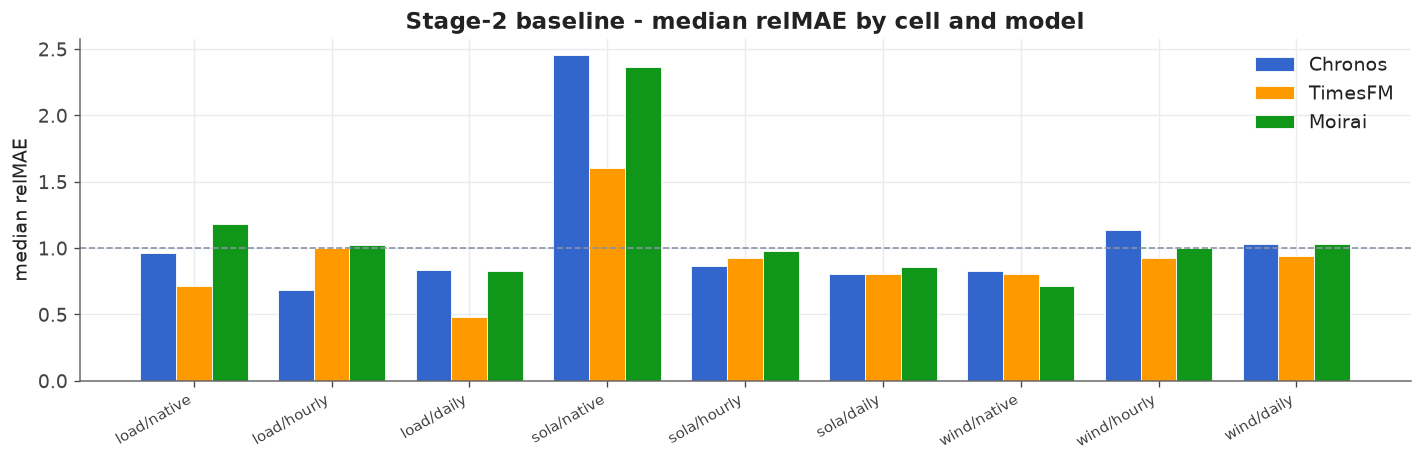

In [4]:
s2 = clean(load("refined_stage2_results.csv"))
tab = s2.pivot_table(index=['etype','gran'], columns='model', values='relMAE', aggfunc='median').round(3)
print("Baseline median relMAE:\n"); print(tab.to_string()); print()

cells=[(e,g) for e in ET for g in GORD]; labels=[f"{e[:4]}/{GLAB[g]}" for e,g in cells]
x=np.arange(len(cells)); w=0.26
fig,ax=plt.subplots(figsize=(12,4))
palette = ['#3366CC', '#FF9900', '#109618', '#DC3912']
MODEL_C = dict(zip(MORD, palette))
for i,m in enumerate(MORD):
    vals=[s2[(s2.etype==e)&(s2.gran==g)&(s2.model==m)].relMAE.median() for e,g in cells]
    ax.bar(x+(i-1)*w, vals, w, color=MODEL_C[m], label=MNAME[m], edgecolor='white', linewidth=0.5)
ax.axhline(1,color=MUTED,ls='--',lw=1)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('median relMAE'); ax.set_title('Stage-2 baseline - median relMAE by cell and model', fontweight='bold')
ax.legend(); plt.tight_layout(); save(fig,'b1_baseline_by_cell'); plt.show()

## 6. RQ1 - Temporal granularity tracks forecast lead time (Stage 3D)

De-confounded design: history **and** lead time are fixed in **physical time**, so granularity is a
genuine treatment. Reading the **13** (type, history, lead) rows across **both** the 7-day and 40-day
histories where >=2 granularities are in contention, **which granularity wins is predicted by the lead
time**. Winner counts: **hourly 6, daily 5, native 2**; **6 of 13 significant** (cluster bootstrap,
5 series). *Native wins only at the 1-hour lead; daily wins at 24-48 h.* Actionable rule: aggregate the
signal to roughly match your forecast lead time.

*Fig RQ1-1:* "Distribution of the winning granularity by forecast lead time, across
all comparable (history, lead) rows. Fine resolution wins only at the shortest lead; coarse resolution
wins from ~6 h ahead."

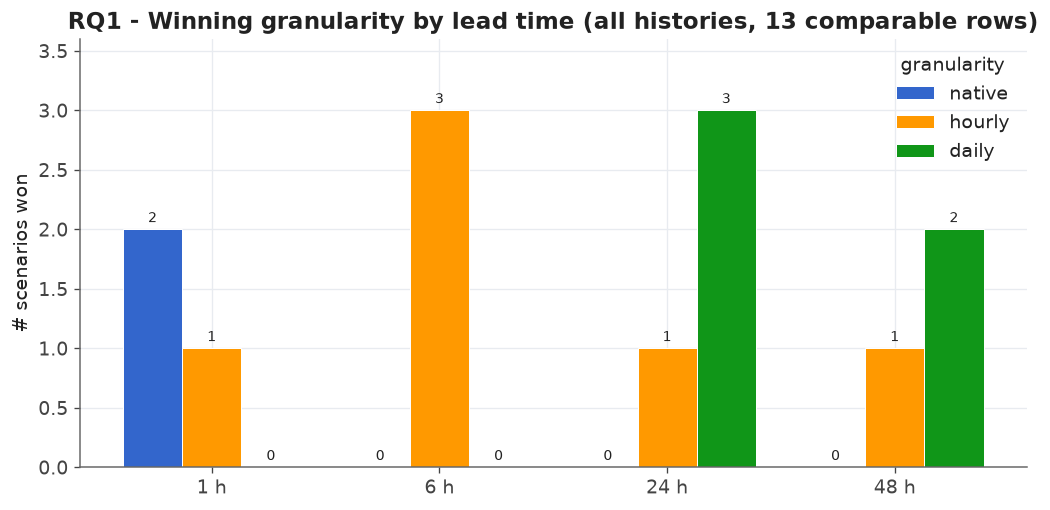

Comparable rows: 13  winners: {'hourly': 6, 'daily': 5, 'minutes (native)': 2}
Native wins only at 1 h lead; daily wins at 24-48 h.


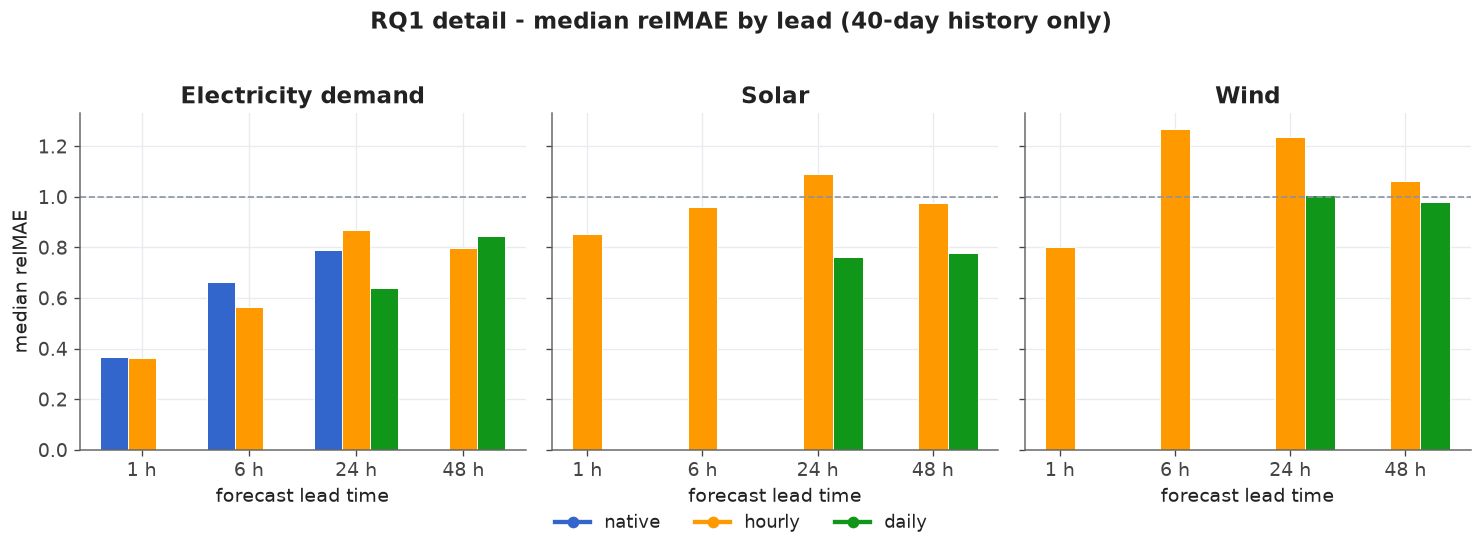

In [5]:
d = clean(load("refined_stage3d_fixed_lead_time.csv"))
leads=['1 h','6 h','24 h','48 h']
# winners across ALL histories (the canonical 13-row result)
best=d.groupby(['etype','history','lead','gran_label']).relMAE.median().reset_index()
idx=best.groupby(['etype','history','lead']).relMAE.idxmin()
n=best.groupby(['etype','history','lead']).size().rename('n')
comp=best.loc[idx].merge(n.reset_index(),on=['etype','history','lead']); comp=comp[comp.n>=2]
GKEY={'minutes (native)':'native','hourly':'1h','daily':'1D'}
wl=comp.assign(g=comp.gran_label.map(GKEY)).groupby(['lead','g']).size().reset_index(name='cnt')
def wc(l,gk):
    r=wl[(wl.lead==l)&(wl.g==gk)]; return int(r.cnt.iloc[0]) if len(r) else 0
x=np.arange(len(leads)); w=0.26
fig,ax=plt.subplots(figsize=(8.8,4.4))
for i,gk in enumerate(GORD):
    ax.bar(x+(i-1)*w,[wc(l,gk) for l in leads],w,color=GRAN_C[gk],label=GLAB[gk],edgecolor='white',linewidth=0.6)
label_bars(ax, fmt="{:.0f}", zero_tag="0")
ax.set_xticks(x); ax.set_xticklabels(leads); ax.set_ylabel('# scenarios won'); ax.set_ylim(0,3.6)
ax.set_title('RQ1 - Winning granularity by lead time (all histories, 13 comparable rows)', fontweight='bold')
ax.legend(title='granularity'); plt.tight_layout(); save(fig,'rq1_winner_by_lead'); plt.show()
print(f"Comparable rows: {len(comp)}  winners: {comp.gran_label.value_counts().to_dict()}")
print("Native wins only at 1 h lead; daily wins at 24-48 h.")

# detail view: median relMAE at the richest single history (40 days)
d40=d[d.history=='40 d']; g=d40.groupby(['etype','lead','gran']).relMAE.median().reset_index()
fig, axes = plt.subplots(1,3,figsize=(12.5,4.3), sharey=True)
for ax,et in zip(axes,ET):
    sub=g[g.etype==et]; Ls=[l for l in leads if l in sub.lead.unique()]; x=np.arange(len(Ls)); w=0.26
    for i,gk in enumerate(GORD):
        vals=[sub[(sub.lead==l)&(sub.gran==gk)].relMAE.median() for l in Ls]
        ax.bar(x+(i-1)*w, vals, w, color=GRAN_C[gk], edgecolor='white', linewidth=0.6)
    ax.axhline(1,color=MUTED,ls='--',lw=1); ax.set_xticks(x); ax.set_xticklabels(Ls)
    ax.set_title(ETN[et],fontweight='bold'); ax.set_xlabel('forecast lead time')
axes[0].set_ylabel('median relMAE')
fig.suptitle('RQ1 detail - median relMAE by lead (40-day history only)', fontweight='bold', y=1.02)
gran_legend(fig); plt.tight_layout(rect=(0,0.02,1,1)); save(fig,'rq1_granularity_by_lead_40d'); plt.show()

### 6.2. RQ1 significance - cluster bootstrap over the 5 series

The winner pattern is backed by a **cluster bootstrap over the five series** (2000 resamples, 95 %):
in each comparable cell the best granularity's per-series relMAE is compared to the runner-up.
**6 of 13 cells are significant** - none at the 1-hour lead (differences are tiny), reaching
significance by 24 h. This is the statistical evidence behind RQ1.

In [6]:
np.random.seed(7)
d = clean(load("refined_stage3d_fixed_lead_time.csv"))
rows=[]
for (et,hist,lead),sub in d.groupby(['etype','history','lead']):
    per=sub.groupby(['gran','series_id']).relMAE.median().reset_index()
    if per.gran.nunique()<2: continue
    med=per.groupby('gran').relMAE.median().sort_values()
    best,second=med.index[0],med.index[1]
    pv=per.pivot(index='series_id',columns='gran',values='relMAE')[[best,second]].dropna()
    if len(pv)<3: continue
    diff=pv[second].values-pv[best].values
    bs=[np.mean(np.random.choice(diff,len(diff),replace=True)) for _ in range(2000)]
    rows.append({'etype':et,'history':hist,'lead':lead,'winner':GLAB.get(best,best),
                 'margin':round(float(med.iloc[1]-med.iloc[0]),3),'significant':bool(np.percentile(bs,2.5)>0)})
sigtab=pd.DataFrame(rows)
print(f"Comparable cells: {len(sigtab)}  |  bootstrap-significant (95%): {int(sigtab.significant.sum())} of {len(sigtab)}\n")
print(sigtab.sort_values(['lead','etype']).to_string(index=False))
print("\nSignificant by lead:"); print(sigtab.groupby('lead').significant.agg(['sum','count']).to_string())

Comparable cells: 13  |  bootstrap-significant (95%): 6 of 13

etype history lead winner  margin  significant
 load    40 d  1 h native   0.041        False
 load     7 d  1 h hourly   0.014        False
solar     7 d  1 h native   0.173        False
 load    40 d 24 h  daily   0.174         True
 load     7 d 24 h hourly   0.163         True
solar    40 d 24 h  daily   0.328         True
 wind    40 d 24 h  daily   0.520        False
 load    40 d 48 h hourly   0.032        False
solar    40 d 48 h  daily   0.196         True
 wind    40 d 48 h  daily   0.095        False
 load    40 d  6 h hourly   0.064         True
 load     7 d  6 h hourly   0.145         True
solar     7 d  6 h hourly   0.160        False

Significant by lead:
      sum  count
lead            
1 h     0      3
24 h    3      4
48 h    1      3
6 h     2      3


### 6.1. RQ1 companion - the feasibility staircase

A result in its own right: at fine metering a long lead needs an enormous number of output steps and a
2048-step context spans only a short history, so many (granularity, history, lead) combinations are
**physically unrepresentable** - **64 of 108 are unreachable**. *Fine granularity buys resolution and
costs reach.*

*Fig RQ1-2:* "Feasible (model-representable) combinations by type and granularity,
out of 12 lead × history combinations each. Wind native reaches only one."

Feasible: 44 of 108  ->  64 unreachable



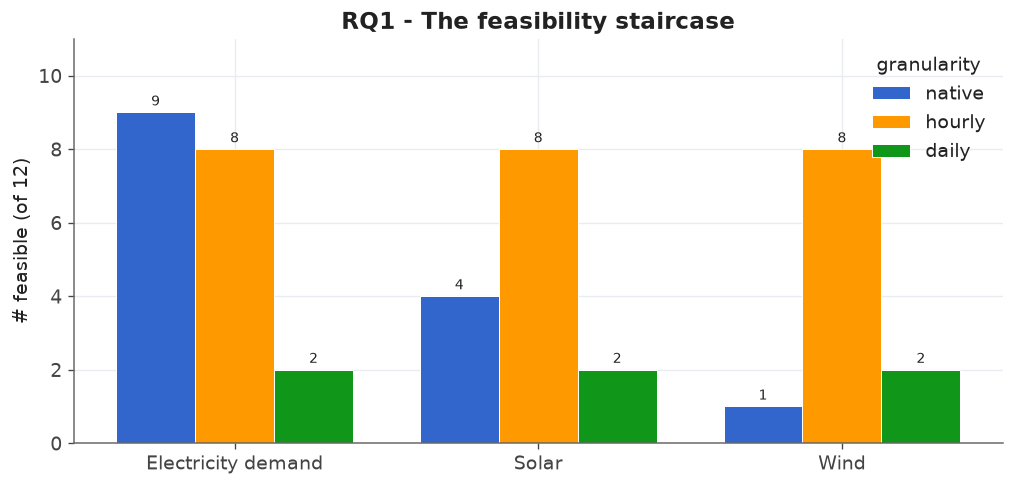

In [7]:
feas = load("refined_stage3d_feasibility.csv")
print(f"Feasible: {int(feas.ok.sum())} of {len(feas)}  ->  {len(feas)-int(feas.ok.sum())} unreachable\n")
piv = feas.pivot_table(index='gran',columns='etype',values='ok',aggfunc='sum').reindex(GORD)
x=np.arange(3); w=0.26
fig,ax=plt.subplots(figsize=(8.6,4.2))
for i,gk in enumerate(GORD):
    ax.bar(x+(i-1)*w,[piv.loc[gk,e] for e in ET],w,color=GRAN_C[gk],label=GLAB[gk],edgecolor='white',linewidth=0.6)
label_bars(ax, fmt="{:.0f}", zero_tag="0")
ax.set_xticks(x); ax.set_xticklabels([ETN[e] for e in ET]); ax.set_ylim(0,11)
ax.set_ylabel('# feasible (of 12)'); ax.set_title('RQ1 - The feasibility staircase', fontweight='bold')
ax.legend(title='granularity'); plt.tight_layout(); save(fig,'rq1_feasibility_staircase'); plt.show()

## 7. RQ2a - Context length: three physically-interpretable regimes (Stage 3B)

Context 128->2048 at fixed horizon. **Load rewards more history throughout** (native 1.043->0.719);
**solar saturates almost immediately**; **wind is actively harmed by more context** (hourly
1.040->1.224 - it is close to a random walk, so extra history is noise).

**Evaluation-coverage caveat (from Stage 3B's planner).** Two cells do not meet the >=14-day / >=30-window
floors and are shown for completeness only: **wind native** (90 windows span just 1.5 days) and any
daily cell. Stage 3B also has **no daily context sweep for solar or wind** (their short daily series
cannot hold a 128->2048 sweep), which is why only native and hourly lines appear for those two.

*Fig RQ2-1:* "Median relMAE versus context length by granularity. Demand improves
monotonically; wind degrades with more context. Wind-native is under-powered (1.5 days evaluated)."

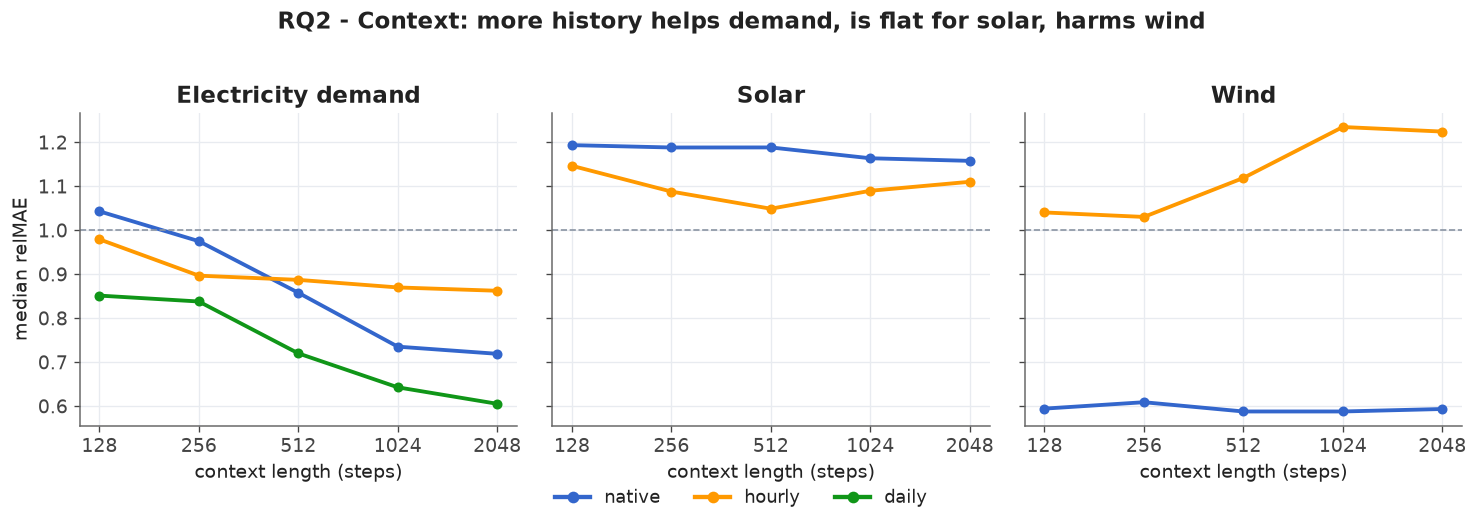

context_steps   128    256    512    1024   2048
etype gran                                      
load  1D       0.851  0.838  0.720  0.642  0.605
      1h       0.979  0.896  0.887  0.870  0.862
      native   1.043  0.975  0.858  0.735  0.719
solar 1h       1.146  1.088  1.049  1.089  1.110
      native   1.193  1.188  1.188  1.163  1.158
wind  1h       1.040  1.030  1.119  1.234  1.224
      native   0.594  0.609  0.588  0.588  0.593


In [8]:
b = clean(load("refined_stage3b_context_sweep.csv"))
g = b.groupby(['etype','gran','context_steps']).relMAE.median().reset_index()
fig, axes = plt.subplots(1,3,figsize=(12.5,4.1), sharey=True)
for ax,et in zip(axes,ET):
    for gk in GORD:
        ss=g[(g.etype==et)&(g.gran==gk)].sort_values('context_steps')
        if not ss.empty: ax.plot(ss.context_steps,ss.relMAE,marker='o',ms=5,lw=2.3,color=GRAN_C[gk])
    ax.axhline(1,color=MUTED,ls='--',lw=1); ax.set_xscale('log',base=2)
    ax.set_xticks([128,256,512,1024,2048]); ax.set_xticklabels([128,256,512,1024,2048])
    ax.set_title(ETN[et],fontweight='bold'); ax.set_xlabel('context length (steps)')
axes[0].set_ylabel('median relMAE')
fig.suptitle('RQ2 - Context: more history helps demand, is flat for solar, harms wind', fontweight='bold', y=1.02)
gran_legend(fig); plt.tight_layout(rect=(0,0.02,1,1)); save(fig,'rq2a_context_sweep'); plt.show()
print(b.pivot_table(index=['etype','gran'],columns='context_steps',values='relMAE',aggfunc='median').round(3).to_string())

## 8. RQ2b - Forecast horizon: the dominant lever at fine granularity (Stage 3C)

Horizon 6→48. Accuracy degrades far more steeply at fine granularity (a longer horizon in *steps* is a
much longer lead in *minutes* there): solar native 0.868→1.772; at daily, load even improves.

*Fig RQ2-2:* "Median relMAE versus forecast horizon by granularity."

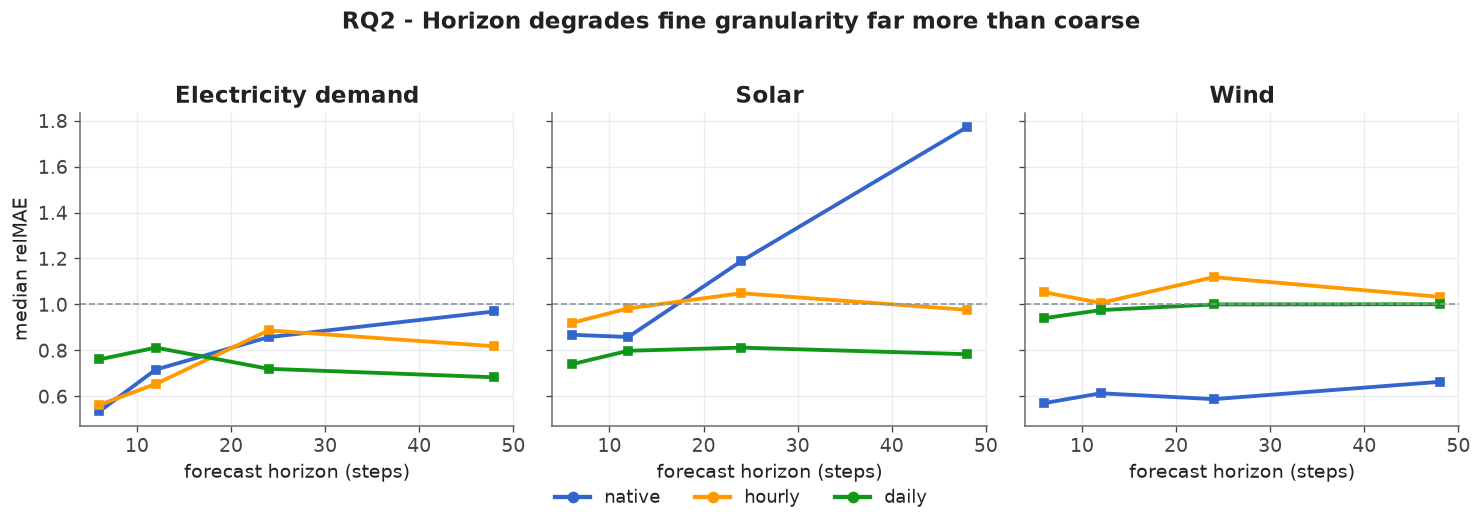

In [9]:
c = clean(load("refined_stage3c_horizon_sweep.csv"))
g = c.groupby(['etype','gran','horizon_steps']).relMAE.median().reset_index()
fig, axes = plt.subplots(1,3,figsize=(12.5,4.1), sharey=True)
for ax,et in zip(axes,ET):
    for gk in GORD:
        ss=g[(g.etype==et)&(g.gran==gk)].sort_values('horizon_steps')
        if not ss.empty: ax.plot(ss.horizon_steps,ss.relMAE,marker='s',ms=5,lw=2.3,color=GRAN_C[gk])
    ax.axhline(1,color=MUTED,ls='--',lw=1)
    ax.set_title(ETN[et],fontweight='bold'); ax.set_xlabel('forecast horizon (steps)')
axes[0].set_ylabel('median relMAE')
fig.suptitle('RQ2 - Horizon degrades fine granularity far more than coarse', fontweight='bold', y=1.02)
gran_legend(fig); plt.tight_layout(rect=(0,0.02,1,1)); save(fig,'rq2b_horizon_sweep'); plt.show()

### 8.1. RQ2 in real-world duration (not just observation counts)

RQ2 asks for the effect *"expressed as both observation counts and real-world temporal duration."* The
sweeps above are in **steps**; re-plotting the context sweep against **history duration in days** shows
why granularities that look aligned by step count are far apart in real time a 2048-step context is
**42.7 days** at 30-min metering but only **1.4 days** at 1-min metering. This is the duration view the
RQ explicitly asks for.

*Fig RQ2-4:* "Median relMAE versus real-world history duration (days, log) by
granularity - the duration counterpart of the step-based context sweep."

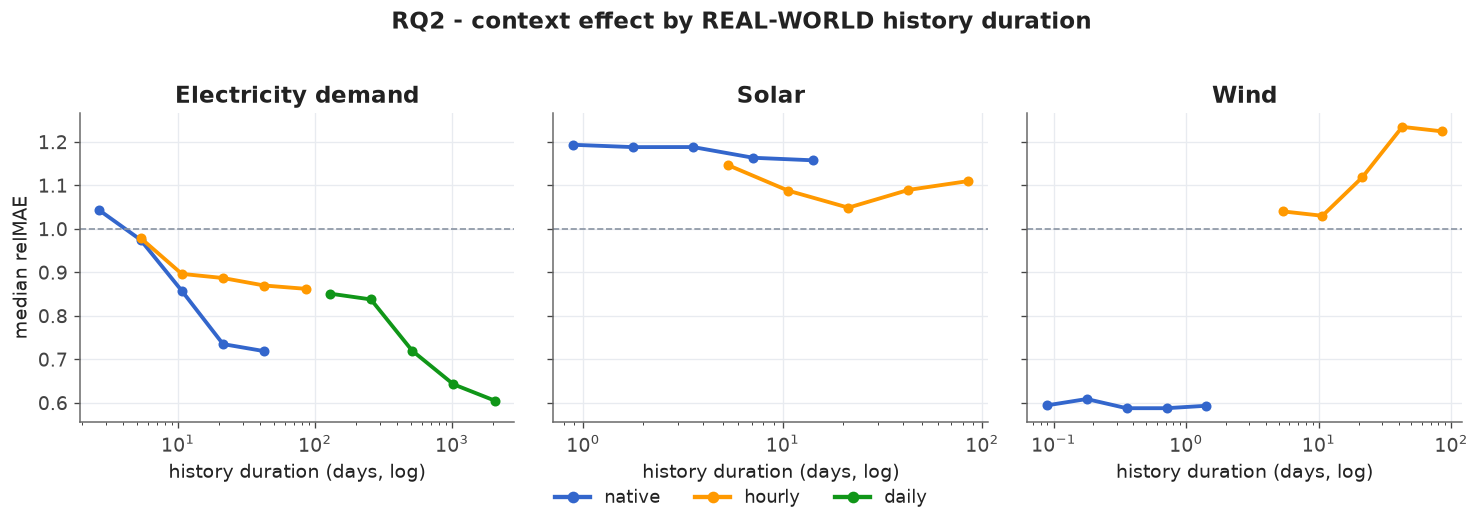

In [10]:
b = clean(load("refined_stage3b_context_sweep.csv"))
b['hist_days'] = b['history_minutes']/1440.0
g = b.groupby(['etype','gran','hist_days']).relMAE.median().reset_index()
fig, axes = plt.subplots(1,3,figsize=(12.5,4.1), sharey=True)
for ax,et in zip(axes,ET):
    for gk in GORD:
        ss=g[(g.etype==et)&(g.gran==gk)].sort_values('hist_days')
        if not ss.empty: ax.plot(ss.hist_days,ss.relMAE,marker='o',ms=5,lw=2.3,color=GRAN_C[gk])
    ax.axhline(1,color=MUTED,ls='--',lw=1); ax.set_xscale('log')
    ax.set_title(ETN[et],fontweight='bold'); ax.set_xlabel('history duration (days, log)')
axes[0].set_ylabel('median relMAE')
fig.suptitle('RQ2 - context effect by REAL-WORLD history duration', fontweight='bold', y=1.02)
gran_legend(fig); plt.tight_layout(rect=(0,0.02,1,1)); save(fig,'rq2d_context_by_duration'); plt.show()

## 9. RQ2c - Does the effect interact with granularity? (Stages 3H, 3I)

**Honest answer: underpowered, not negative.** Stage 3I tests the interaction at the correct unit
(per-series slopes, paired across granularities): **0 of 6 survive Holm correction at n = 5**, though
three sit at raw p ≈ 0.015–0.022. Window-level p-values are tiny but treat overlapping windows as
independent. Stage 3H (context × horizon, native only) finds the interaction significant only for load
and negligible in effect size (R² +0.0009). With five series a two-sided test cannot reach p < 0.0625
for a two-granularity cell — **the design caps the power.**

*Fig RQ2-3:* "Interaction effect size (ΔR²) of configuration × granularity by
energy type; none survives Holm correction at n = 5 (series level)."

Stage 3I - granularity interaction (series-level test):

 factor etype    dR2  p_window_level  p_series_level  p_series_holm                                                verdict
context  load 0.0042          0.0000          0.0150         0.0900 visible at window level, NOT established with 5 series
context solar 0.0016          0.0022          0.0625         0.1875 visible at window level, NOT established with 5 series
context  wind 0.0002          0.2282          0.6250         0.9447                                            no evidence
horizon  load 0.0118          0.0000          0.0224         0.0900 visible at window level, NOT established with 5 series
horizon solar 0.0194          0.0000          0.0150         0.0900 visible at window level, NOT established with 5 series
horizon  wind 0.0008          0.0764          0.4724         0.9447                                            no evidence

Series-level Holm-significant: 0 of 6  => underpowered at n=5



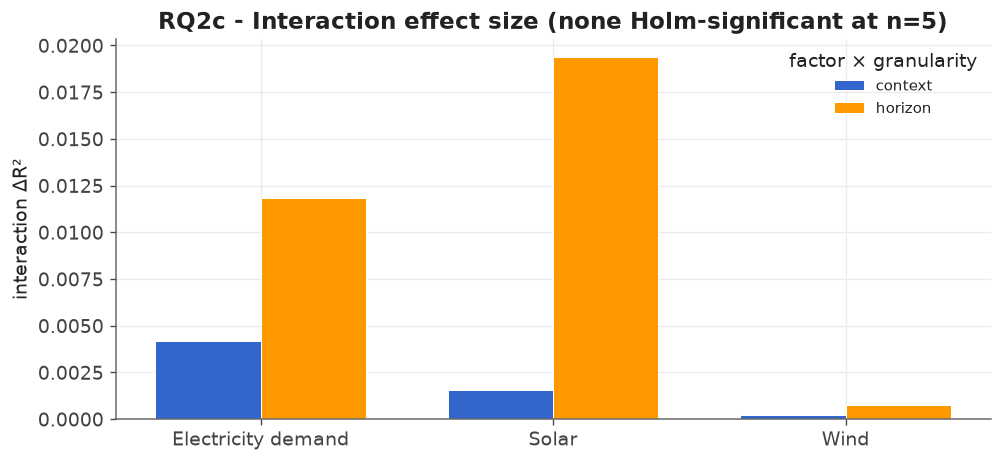

Stage 3H - context×horizon interaction (native):

etype     n  coef_context  coef_horizon  interaction_coef  R2_no_interaction  R2_with  p_interaction
 load  7200       -0.0519        0.0678           -0.0111             0.0417   0.0426         0.0097
solar  3924       -0.0327        0.2028           -0.0099             0.0905   0.0907         0.2892
 wind 11796        0.0282        0.0657           -0.0082             0.0141   0.0143         0.1058


In [11]:
i = load("refined_stage3i_granularity_interaction.csv")
show=[c for c in ['factor','etype','dR2','p_window_level','p_series_level','p_series_holm','verdict'] if c in i.columns]
print("Stage 3I - granularity interaction (series-level test):\n"); print(i[show].round(4).to_string(index=False)); print()
print(f"Series-level Holm-significant: {int((i.p_series_holm<0.05).sum())} of {len(i)}  => underpowered at n=5\n")

# ΔR2 bar by factor x etype
fig,ax=plt.subplots(figsize=(8.5,4))
facs=sorted(i.factor.unique()); x=np.arange(len(ET)); w=0.36
for k,fac in enumerate(facs):
    vals=[float(i[(i.etype==e)&(i.factor==fac)].dR2.iloc[0]) if len(i[(i.etype==e)&(i.factor==fac)]) else 0 for e in ET]
    ax.bar(x+(k-0.5)*w, vals, w, label=fac, color=['#3366CC', '#FF9900'][k%2], edgecolor='white', linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels([ETN[e] for e in ET]); ax.set_ylabel('interaction ΔR²')
ax.set_title('RQ2c - Interaction effect size (none Holm-significant at n=5)', fontweight='bold')
ax.legend(title='factor × granularity', fontsize=9); plt.tight_layout(); save(fig,'rq2c_interaction_dr2'); plt.show()

h = load("refined_stage3h_interaction_test.csv")
print("Stage 3H - context×horizon interaction (native):\n"); print(h.round(4).to_string(index=False))

## 10. Statistical significance (Stage 3E, Holm-corrected)

Paired Wilcoxon tests with Holm correction. **Context effects: 25 of 84 comparisons survive Holm**
(up from 4 before the window-count fix, §17). **Model comparison: 10 of 27 survive - TimesFM 7,
Chronos 3, Moirai 0.**

*Fig E-1:* "Holm-surviving context-step comparisons per energy type (of 84 total)."

Context comparisons surviving Holm: 25 of 84


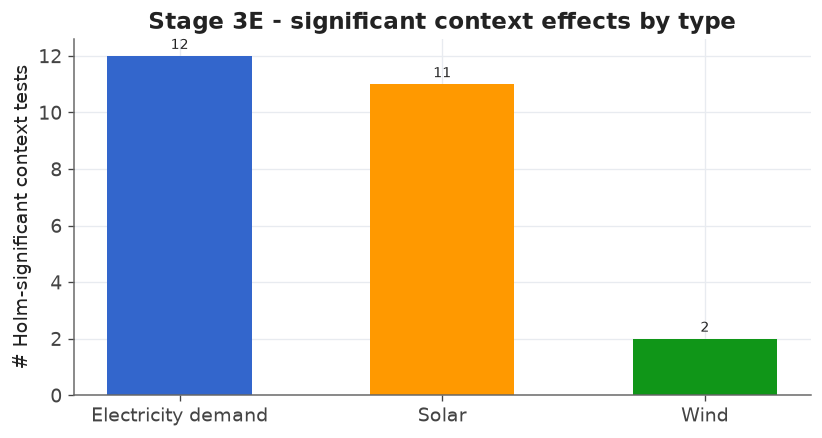


Model comparisons surviving Holm: 10 of 27  ->  wins: {'timesfm': 7, 'chronos': 3}


In [12]:
ce = load("refined_stage3e_context_significance_holm.csv")
print(f"Context comparisons surviving Holm: {int(ce.significant_holm.sum())} of {len(ce)}")
cnt = ce[ce.significant_holm].groupby('etype').size().reindex(ET).fillna(0)
fig,ax=plt.subplots(figsize=(7,3.8))
ax.bar([ETN[e] for e in ET],[cnt[e] for e in ET],color=[GRAN_C['native'],GRAN_C['1h'],GRAN_C['1D']],width=0.55)
label_bars(ax, fmt="{:.0f}", zero_tag="0")
ax.set_ylabel('# Holm-significant context tests'); ax.set_title('Stage 3E - significant context effects by type', fontweight='bold')
plt.tight_layout(); save(fig,'e1_context_significance'); plt.show()

me = load("refined_stage3e_model_significance.csv")
if me is not None and 'significant_holm' in me.columns:
    print(f"\nModel comparisons surviving Holm: {int(me.significant_holm.sum())} of {len(me)}"
          f"  ->  wins: {me[me.significant_holm].winner.value_counts().to_dict()}")

## 11. RQ3 - Accuracy vs inference cost, and deployability (Stages 3J, 3F)

Once cost counts the recommendation changes. TimesFM is most accurate but ~16× the cost of Chronos.
On a Pareto frontier **314 of 333 configurations are dominated**; **Chronos owns the entire solar
frontier and 7/8 of wind**.

*Fig RQ3-1:* "Median relMAE versus inference time per forecast (log scale) by
model. Ringed points are Pareto-optimal."

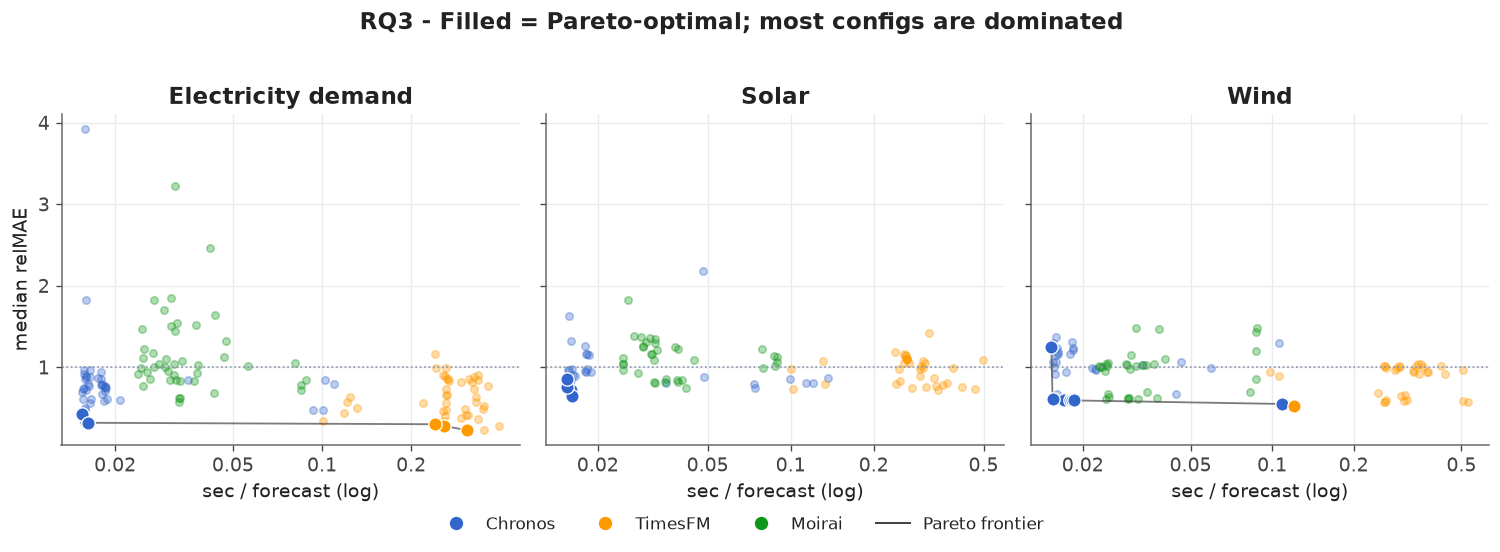

Dominated: 314 of 333
  load   frontier: {'chronos': 4, 'timesfm': 3}
  solar  frontier: {'chronos': 4}
  wind   frontier: {'chronos': 7, 'timesfm': 1}


In [13]:
import matplotlib.ticker as _mt
_rq3_ticks=[0.02,0.05,0.1,0.2,0.5]
def _rq3fmt(v,pos): return '%g'%v
j = load("refined_stage3j_configurations_with_cost.csv")
fig, axes = plt.subplots(1,3,figsize=(12.8,4.3), sharey=True)
for ax,et in zip(axes,ET):
    gg=j[j.etype==et]
    for m in MORD:
        mm=gg[gg.model==m]; dom=mm[~mm.pareto]; par=mm[mm.pareto]
        ax.scatter(dom.infer_sec,dom.median_relMAE,s=20,color=MODEL_C[m],alpha=0.33)
        ax.scatter(par.infer_sec,par.median_relMAE,s=64,color=MODEL_C[m],edgecolor='white',linewidth=0.8,zorder=5)
    f=gg[gg.pareto].sort_values('infer_sec')
    ax.plot(f.infer_sec,f.median_relMAE,color='#444',lw=1.1,alpha=0.7,zorder=4)
    ax.axhline(1,color=MUTED,ls=':',lw=1); ax.set_xscale('log')
    ax.xaxis.set_major_locator(_mt.FixedLocator(_rq3_ticks))
    ax.xaxis.set_minor_locator(_mt.NullLocator())
    ax.xaxis.set_major_formatter(_mt.FuncFormatter(_rq3fmt))
    ax.set_title(ETN[et],fontweight='bold'); ax.set_xlabel('sec / forecast (log)')
axes[0].set_ylabel('median relMAE')
h=[Line2D([0],[0],marker='o',color='none',markerfacecolor=MODEL_C[m],markeredgecolor='white',ms=9,label=MNAME[m]) for m in MORD]
h.append(Line2D([0],[0],color='#444',lw=1.2,label='Pareto frontier'))
fig.legend(handles=h,loc='lower center',ncol=4,bbox_to_anchor=(0.5,-0.02),fontsize=10)
fig.suptitle('RQ3 - Filled = Pareto-optimal; most configs are dominated', fontweight='bold', y=1.02)
plt.tight_layout(rect=(0,0.03,1,1)); save(fig,'rq3_pareto_cost'); plt.show()
print(f"Dominated: {int((~j.pareto).sum())} of {len(j)}")
for et in ET: print(f"  {et:6s} frontier:", j[(j.etype==et)&j.pareto].model.value_counts().to_dict())

### 11.1. Deployable configurations & scenario trade-off (Stage 3F, 3J)

The operational deliverable: the best configuration per type that **beats the naive benchmark**, read
with worst-series and p90 tail risk; and what accuracy costs per operational scenario.

In [14]:
sel = load("refined_stage3f_selection_matrix.csv")
dep = sel[sel.deployable] if 'deployable' in sel.columns else sel[sel.median_relMAE<1]
best = dep.loc[dep.groupby('etype').median_relMAE.idxmin()]
cols=[c for c in ['etype','gran_label','history','lead','model','median_relMAE','worst_series_relMAE','p90_relMAE'] if c in best.columns]
print("Best deployable configuration per type:\n"); print(best[cols].round(3).to_string(index=False))
# canonical count from Stage 3F (matches the 3F notebook headline)
allc = load("refined_stage3f_all_configurations.csv")
print(f"\nConfigurations beating the seasonal-naive benchmark (Stage 3F): "
      f"{int((allc.median_relMAE<1).sum())} of {len(allc)}   "
      f"[selection-matrix job-slots: {int(sel.deployable.sum())} of {len(sel)}]\n")
sc = load("refined_stage3j_scenario_matrix.csv")
if sc is not None:
    sco=[c for c in ['etype','scenario','cheapest','cheap_relMAE','most_accurate','acc_relMAE','sec_per_0.01_relMAE'] if c in sc.columns]
    print("Scenario accuracy-vs-cost trade-off:\n"); print(sc[sco].round(3).to_string(index=False))

Best deployable configuration per type:

etype       gran_label history  lead   model  median_relMAE  worst_series_relMAE  p90_relMAE
 load minutes (native)  40.0 d 1.0 h timesfm          0.227                0.438       1.265
solar           hourly   7.0 d 1.0 h chronos          0.644                0.895       5.782
 wind minutes (native)   8.5 h 6 min timesfm          0.522                0.685       1.571

Configurations beating the seasonal-naive benchmark (Stage 3F): 216 of 333   [selection-matrix job-slots: 96 of 111]

Scenario accuracy-vs-cost trade-off:

etype                      scenario                 cheapest  cheap_relMAE            most_accurate  acc_relMAE  sec_per_0.01_relMAE
 load day-ahead and beyond (> 24 h)           chronos/hourly         0.695            timesfm/daily       0.278                0.006
 load intra-hour balancing (<= 1 h) chronos/minutes (native)         0.424 timesfm/minutes (native)       0.227                0.015
 load  same-day scheduling (6-2

### 11.2. Model board - best achievable relMAE by model × cell

*Fig RQ3-2:* "Best-configuration median relMAE for each model in each cell
(green = strong, red = weak). TimesFM leads on load; all models struggle on wind daily."

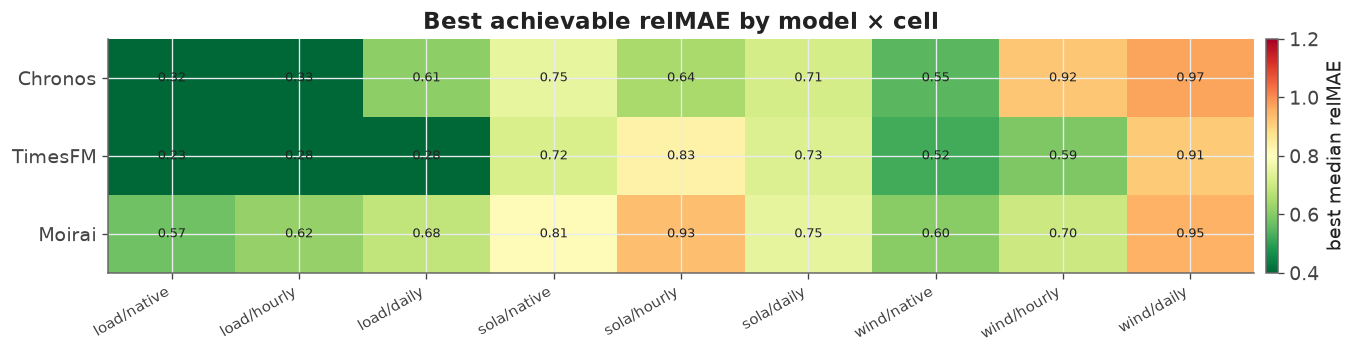

In [15]:
allc = load("refined_stage3f_all_configurations.csv")
bb = allc.groupby(['etype','gran','model']).median_relMAE.min().reset_index()
cells=[(e,g) for e in ET for g in GORD]; labels=[f"{e[:4]}/{GLAB[g]}" for e,g in cells]
M=np.full((3,len(cells)),np.nan)
for jx,(e,g) in enumerate(cells):
    for ix,m in enumerate(MORD):
        r=bb[(bb.etype==e)&(bb.gran==g)&(bb.model==m)]
        if len(r): M[ix,jx]=r.iloc[0].median_relMAE
fig,ax=plt.subplots(figsize=(11.5,3.1))
im=ax.imshow(M,aspect='auto',cmap='RdYlGn_r',vmin=0.4,vmax=1.2)
ax.set_xticks(range(len(cells))); ax.set_xticklabels(labels,rotation=30,ha='right',fontsize=9)
ax.set_yticks(range(3)); ax.set_yticklabels([MNAME[m] for m in MORD])
for ix in range(3):
    for jx in range(len(cells)):
        if not np.isnan(M[ix,jx]): ax.text(jx,ix,f"{M[ix,jx]:.2f}",ha='center',va='center',fontsize=8)
fig.colorbar(im,ax=ax,fraction=0.025,pad=0.01).set_label('best median relMAE')
ax.set_title('Best achievable relMAE by model × cell', fontweight='bold')
plt.tight_layout(); save(fig,'rq3_model_board_heatmap'); plt.show()

## 12. Model comparison - accuracy vs economy

Win rate (lowest relMAE per window) vs median inference cost. **TimesFM 47.8 % wins, Chronos 33.7 %,
Moirai 18.5 %**; Chronos is ~16× cheaper than TimesFM.

*Fig M-1:* "Per-window win rate and median inference cost per model."

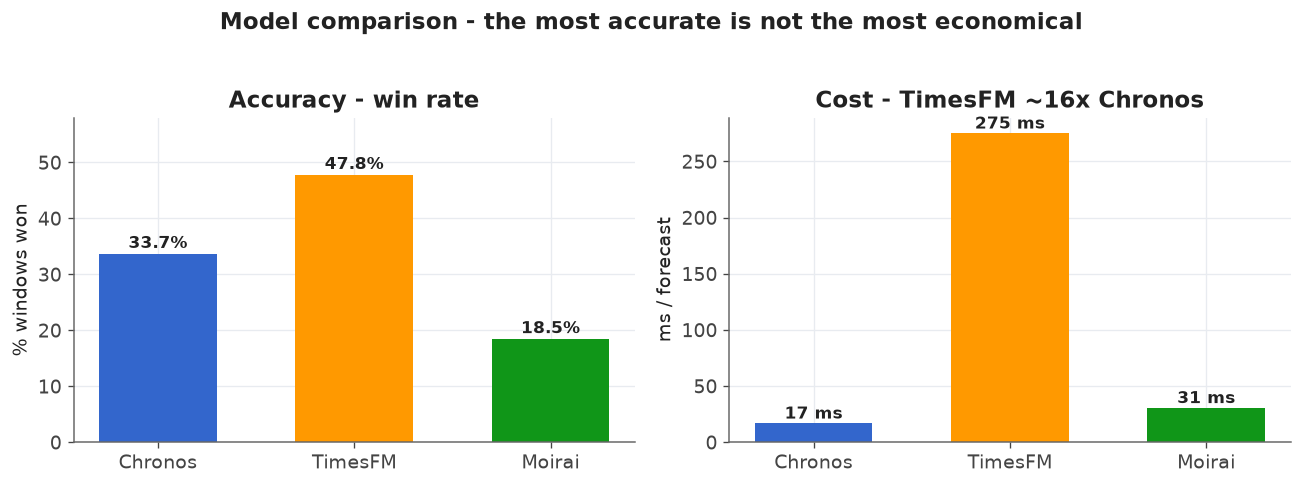

In [16]:
key=['etype','gran','series_id','origin_index','context_steps','horizon_steps']
piv=allr.pivot_table(index=key,columns='model',values='relMAE').dropna()
win=(piv.idxmin(axis=1).value_counts(normalize=True)*100)
cost=allr.groupby('model').infer_sec.median()
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,3.9))
a1.bar([MNAME[m] for m in MORD],[win.get(m,0) for m in MORD],color=[MODEL_C[m] for m in MORD],width=0.6)
for k,m in enumerate(MORD): a1.text(k,win.get(m,0)+1,f"{win.get(m,0):.1f}%",ha='center',fontweight='bold',fontsize=10)
a1.set_ylabel('% windows won'); a1.set_ylim(0,58); a1.set_title('Accuracy - win rate', fontweight='bold')
a2.bar([MNAME[m] for m in MORD],[cost[m]*1000 for m in MORD],color=[MODEL_C[m] for m in MORD],width=0.6)
for k,m in enumerate(MORD): a2.text(k,cost[m]*1000+4,f"{cost[m]*1000:.0f} ms",ha='center',fontweight='bold',fontsize=10)
a2.set_ylabel('ms / forecast'); a2.set_title('Cost - TimesFM ~16x Chronos', fontweight='bold')
fig.suptitle('Model comparison - the most accurate is not the most economical', fontweight='bold', y=1.03)
plt.tight_layout(); save(fig,'m1_model_comparison'); plt.show()

## 13. RQ4 - Predicting deployability on an unseen energy type (Stage 3G)

Leave-one-energy-type-out: a rule on series descriptors (zero-inflation, volatility, seasonal
structure) predicts deployability on the held-out type. **Works for load and solar; fails for wind**
    because wind's own mean already predicts its performance (baseline MAE 0.090, lowest), leaving little
variance to explain.

*Fig RQ4-1:* "Leave-one-type-out: descriptor-model prediction error vs a mean
baseline; Spearman of predicted vs actual deployability annotated."

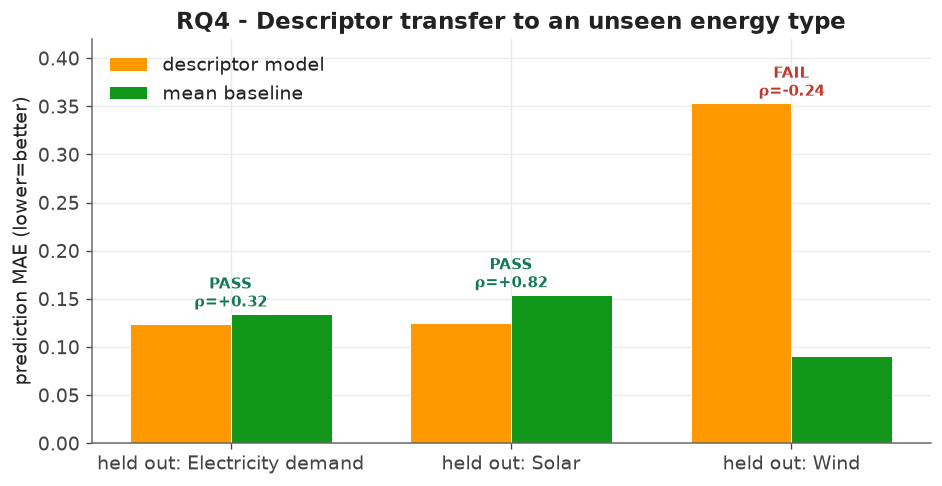

held_out  MAE_model  MAE_mean_baseline  spearman_pred_vs_actual     p  beats_baseline
    load      0.124              0.134                    0.315 0.035            True
   solar      0.125              0.154                    0.820 0.000            True
    wind      0.353              0.090                   -0.242 0.122           False


In [17]:
gg = load("refined_stage3g_leave_one_type_out.csv")
gg['etype']=pd.Categorical(gg.held_out,ET,ordered=True); gg=gg.sort_values('etype')
x=np.arange(len(gg)); w=0.36
fig,ax=plt.subplots(figsize=(8,4.2))
ax.bar(x-w/2,gg.MAE_model,w,label='descriptor model',color='#FF9900',edgecolor='white',linewidth=0.6)
ax.bar(x+w/2,gg.MAE_mean_baseline,w,label='mean baseline',color='#109618',edgecolor='white',linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels([f"held out: {ETN[e]}" for e in gg.held_out])
ax.set_ylabel('prediction MAE (lower=better)')
for k,(_,r) in enumerate(gg.iterrows()):
    tag='PASS' if r.beats_baseline else 'FAIL'; col='#157a52' if r.beats_baseline else '#bd3b2c'
    ax.text(k, max(r.MAE_model,r.MAE_mean_baseline)+0.008, f"{tag}\nρ={r.spearman_pred_vs_actual:+.2f}",
            ha='center', fontsize=9, color=col, fontweight='bold')
ax.set_ylim(0,0.42); ax.set_title('RQ4 - Descriptor transfer to an unseen energy type', fontweight='bold')
ax.legend(); plt.tight_layout(); save(fig,'rq4_descriptor_transfer'); plt.show()
print(gg[['held_out','MAE_model','MAE_mean_baseline','spearman_pred_vs_actual','p','beats_baseline']].round(3).to_string(index=False))

### 13.1. RQ4 - which characteristics actually drive forecastability?

RQ4 names **zero-inflation, volatility and seasonal structure**. Ranking all nine descriptors by
|Spearman| with log relMAE (132 series×granularity×model rows) shows **volatility (cv) and
zero-inflation are the strongest predictors** of poor accuracy, while **seasonal strength alone is
weak** forecastability is driven by irregularity, not by having a clean cycle. This quantifies the
"explained by measurable characteristics" claim rather than asserting it.

*Fig RQ4-2:* "Absolute Spearman correlation of each series descriptor with log
relMAE; the three descriptors named in RQ4 are highlighted."

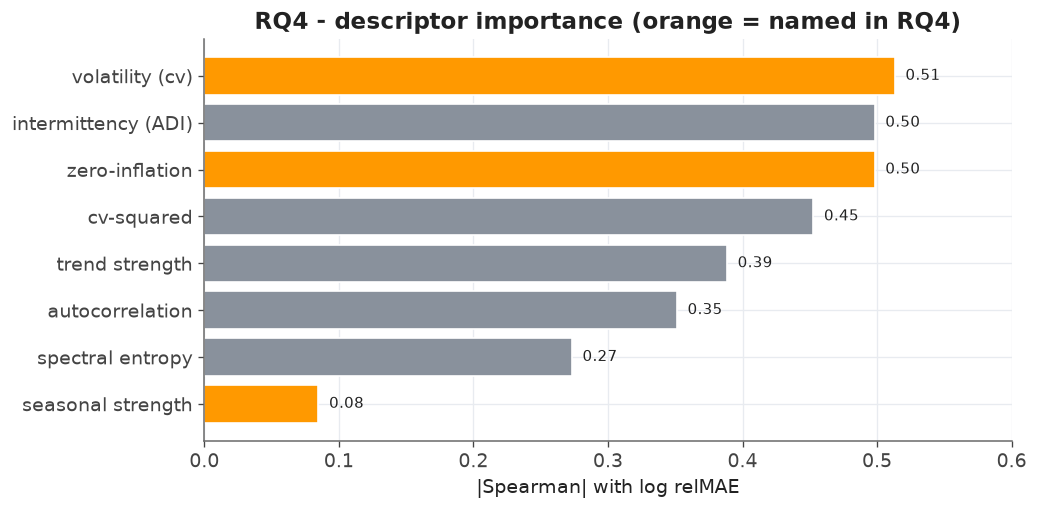

Drivers (|rho|): {'volatility (cv)': 0.513, 'zero-inflation': 0.498, 'intermittency (ADI)': 0.498, 'cv-squared': 0.453, 'trend strength': 0.388, 'autocorrelation': 0.351, 'spectral entropy': 0.273, 'seasonal strength': 0.085}


In [18]:
from scipy.stats import spearmanr
f = load("refined_stage3g_features.csv")
descs={'cv':'volatility (cv)','pct_zero':'zero-inflation','seasonal_strength':'seasonal strength',
       'adi':'intermittency (ADI)','cv2':'cv-squared','acf1':'autocorrelation',
       'trend_strength':'trend strength','spectral_entropy':'spectral entropy'}
rho={lab:abs(spearmanr(f[c],f['log_relMAE']).correlation) for c,lab in descs.items()}
rho=dict(sorted(rho.items(), key=lambda x:x[1]))
named={'volatility (cv)','zero-inflation','seasonal strength'}
fig,ax=plt.subplots(figsize=(8.8,4.4))
ax.barh(list(rho.keys()), list(rho.values()),
        color=['#FF9900' if k in named else "#89919c" for k in rho], edgecolor='white')
for i,(k,v) in enumerate(rho.items()): ax.text(v+0.008,i,f"{v:.2f}",va='center',fontsize=9)
ax.set_xlabel('|Spearman| with log relMAE'); ax.set_xlim(0,0.6)
ax.set_title('RQ4 - descriptor importance (orange = named in RQ4)', fontweight='bold')
plt.tight_layout(); save(fig,'rq4_descriptor_importance'); plt.show()
print("Drivers (|rho|):", {k:round(v,3) for k,v in sorted(rho.items(),key=lambda x:-x[1])})

## 14. Benchmark robustness - the key negative result about wind (Stage 3K)

Re-scoring every forecast against a **random-walk** benchmark (repeat last value) instead of
seasonal-naive: **wind native collapses from relMAE 0.61 to 0.99** the models are no better than a
trivial random walk. Its strong seasonal-naive score was an artefact of an inappropriate benchmark
(wind has no reliable daily cycle). Solar behaves oppositely a real daily cycle makes seasonal-naive
the strong benchmark.

*Fig RQ-K1:* "Median relMAE under seasonal-naive vs random-walk benchmarks, by
cell. Bars past 1.0 are worse than the benchmark."

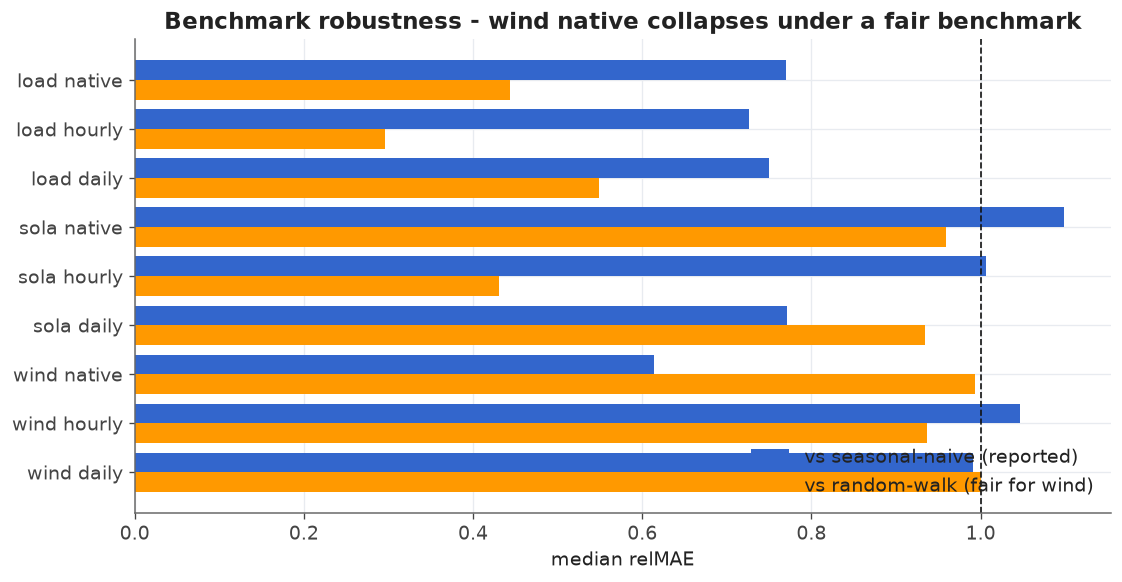

Wind native: seasonal 0.614 -> random-walk 0.994
Finding: foundation models do NOT beat a random walk on high-frequency wind.


In [19]:
k = load("refined_stage3k_benchmark_comparison.csv")
k=k.copy(); k['g']=k.gran.map(lambda x:GLAB.get(x,x))
order=[(e,g) for e in ET for g in ['native','1h','1D']]
k['ord']=k.apply(lambda r:order.index((r.etype,r.gran)),axis=1); k=k.sort_values('ord')
labels=[f"{e[:4]} {GLAB[g]}" for e,g in order]
yy=np.arange(len(k));
fig,ax=plt.subplots(figsize=(9.5,5))
ax.barh(yy-0.2,k.relMAE_seasonal,0.4,label='vs seasonal-naive (reported)',color='#3366CC')
ax.barh(yy+0.2,k.relMAE_randomwalk,0.4,label='vs random-walk (fair for wind)',color='#FF9900')
ax.axvline(1,color='#111',ls='--',lw=1); ax.set_yticks(yy); ax.set_yticklabels(labels)
ax.set_xlabel('median relMAE'); ax.invert_yaxis(); ax.legend(loc='lower right')
ax.set_title('Benchmark robustness - wind native collapses under a fair benchmark', fontweight='bold')
plt.tight_layout(); save(fig,'rqk_benchmark_robustness'); plt.show()
wn=k[(k.etype=='wind')&(k.gran=='native')].iloc[0]
print(f"Wind native: seasonal {wn.relMAE_seasonal:.3f} -> random-walk {wn.relMAE_randomwalk:.3f}")
print("Finding: foundation models do NOT beat a random walk on high-frequency wind.")

## 15. H4 - Zero-inflation and aggregation (solar natural experiment)

Solar is exactly zero at night (~55 % of native samples). Aggregating to daily removes the zeros
entirely and accuracy recovers. To keep this consistent with the RQ2 figures, both the zero-fraction
bars **and** the relMAE line are read from a **single source — the horizon sweep (Stage 3C)**, which
carries all three solar granularities and matches the RQ2 magnitude (native 1.08 -> daily 0.77).

*Fig H4-1:* "Solar: median exact-zero fraction (bars) and median relMAE from the
horizon sweep (line) across granularities. Removing night-time zeros by aggregation restores accuracy."

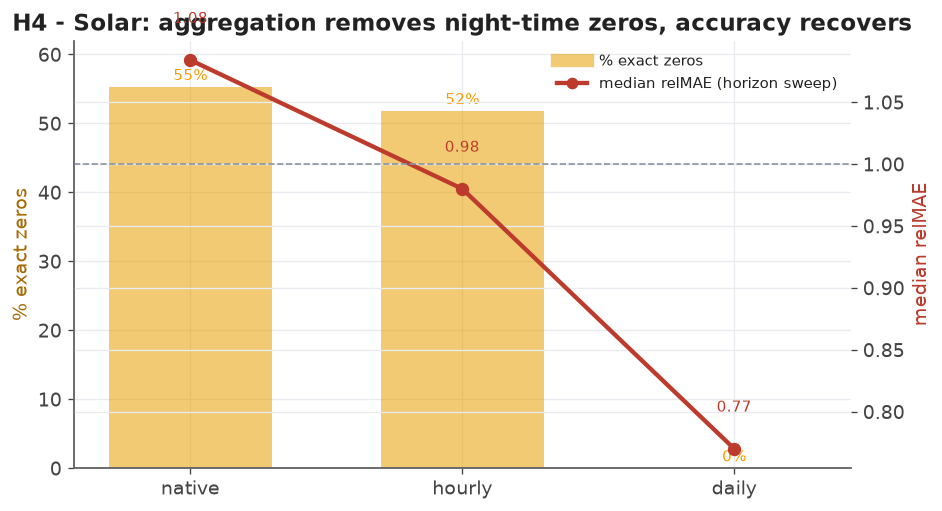

solar %zeros (median): {'native': 55.3, '1h': 51.8, '1D': 0.0}
solar relMAE (3C): {'native': 1.084, 'hourly': 0.98, 'daily': 0.77}


In [20]:
a = load("refined_stage3a_characteristics.csv")
c3 = clean(load("refined_stage3c_horizon_sweep.csv"))
z = a.groupby(['etype','gran']).pct_zero.median().unstack()          # median, matches Stage 3A
solz=[z.loc['solar',g] for g in GORD]
solr=[c3[(c3.etype=='solar')&(c3.gran==g)].relMAE.median() for g in GORD]   # single source: horizon sweep 3C
xx=['native','hourly','daily']
fig,ax=plt.subplots(figsize=(8,4.4)); ax2=ax.twinx()
ax.bar(xx,solz,color='#E69F00',alpha=0.55,width=0.6,label='% exact zeros')
for k,v in enumerate(solz): ax.text(k,v+1,f"{v:.0f}%",ha='center',fontsize=9,color='#FF9900')
ax2.plot(xx,solr,marker='o',ms=7,lw=2.6,color='#bd3b2c',label='median relMAE (horizon sweep 3C)')
ax2.axhline(1,color=MUTED,ls='--',lw=1)
for k,v in enumerate(solr): ax2.text(k,v+0.03,f"{v:.2f}",ha='center',fontsize=9,color='#bd3b2c')
ax.set_ylabel('% exact zeros', color='#a76b06'); ax2.set_ylabel('median relMAE', color='#bd3b2c')
ax.set_ylim(0,62); ax.set_title('H4 - Solar: aggregation removes night-time zeros, accuracy recovers', fontweight='bold')
lines=[Line2D([0],[0],color='#E69F00',lw=8,alpha=0.55,label='% exact zeros'),
       Line2D([0],[0],color='#bd3b2c',lw=2.6,marker='o',label='median relMAE (horizon sweep)')]
ax.legend(handles=lines, loc='upper right', fontsize=9)
plt.tight_layout(); save(fig,'h4_solar_zero_inflation'); plt.show()
print("solar %zeros (median):", {g:round(z.loc['solar',g],1) for g in GORD})
print("solar relMAE (3C):", {GLAB[g]:round(v,3) for g,v in zip(GORD,solr)})

## 16. Fairness check - Moirai patch_size (Stage 3L, a known limitation)

Moirai is run with `patch_size = 32`. Stage 3L attempted to re-run with `patch_size = "auto"` to
check fairness, but **the "auto" path failed** in the installed `uni2ts` version (every forecast raised
an exception the wrapper swallowed, so `moirai_auto` is empty). With the validated `patch_size = 32`,
**Moirai loses every cell to Chronos/TimesFM**, so "Moirai never wins" is defensible but the `auto`
comparison remains open and Moirai's last place should carry this caveat plus the capacity/identity
confound (it is also the smallest model, ~14 M).

In [21]:
mb = load("refined_stage3l_model_board.csv")
if mb is not None:
    cols=[c for c in ['etype','gran','chronos','timesfm','moirai_32','moirai_auto','best_with_moirai32','changed'] if c in mb.columns]
    print("Stage 3L model board (moirai_auto is empty the 'auto' path failed):\n")
    print(mb[cols].to_string(index=False))
    print(f"\nmoirai_auto non-null rows: {int(mb['moirai_auto'].notna().sum())} of {len(mb)}  (0 => auto never scored)")

Stage 3L model board (moirai_auto is empty the 'auto' path failed):

etype   gran  chronos  timesfm  moirai_32  moirai_auto best_with_moirai32  changed
 load     1D 0.794705 0.497531        NaN          NaN            timesfm    False
 load     1h 0.629572 0.665427        NaN          NaN            chronos    False
 load native 0.724919 0.473384        NaN          NaN            timesfm    False
solar     1D 0.768910 0.751739        NaN          NaN            timesfm    False
solar     1h 0.891369 1.015593        NaN          NaN            chronos    False
solar native 1.125001 1.022616        NaN          NaN            timesfm    False
 wind     1D 0.992844 0.952438        NaN          NaN            timesfm    False
 wind     1h 1.157915 0.967359        NaN          NaN            timesfm    False
 wind native 0.616483 0.589063        NaN          NaN            timesfm    False

moirai_auto non-null rows: 0 of 9  (0 => auto never scored)


## 17 · Errors & methodological corrections (contributions of general relevance)

Two defects were found and fixed; each changed reported numbers and **generalises beyond this thesis**.

**(1) A scale-free metric computed on the *context window* confounds the treatment.** The original MASE
denominator changed as the sweep changed the context (wind native scale collapsed to 1.04 vs 22.05
daily for one physical signal). Fixed to a reserved segment → wind native median MASE fell from
**19.677 to 0.309**; primary metric switched to **relMAE**.

**(2) Fixing the evaluation *window count* instead of *duration* under-powers high-frequency cells.**
One window spans `horizon × step_minutes` of real time 5 windows = 2.5 days of load but 2 hours of
wind. Re-running with **planned window counts** *reversed the sign of the context effect in 3 of 7
cells* and raised Holm-surviving context tests from **4 to 25**.

The tables below show the window-count sensitivity directly (5-window vs planned).

In [22]:
for f,label in [("refined_stage3b_window_count_sensitivity.csv","3B — context effect (5-window vs planned)"),
                ("refined_stage3d_window_count_sensitivity.csv","3D — granularity winner (5-window vs planned)")]:
    s=load(f)
    if s is not None:
        print(f"=== {label} ===\n{s.round(3).to_string(index=False)}\n")

=== 3B — context effect (5-window vs planned) ===
etype       gran_label  ctx_lo_o  ctx_hi_o  old_lo  old_hi  old_5win  ctx_lo_n  ctx_hi_n  new_lo  new_hi  new_planned  sign_flip
 load            daily       128      2048   0.938   0.803    14.447       128      2048   0.851   0.605       28.914      False
 load           hourly       128      2048   1.057   0.827    21.743       128      2048   0.979   0.862       11.949      False
 load minutes (native)       128      2048   1.135   1.162    -2.376       128      2048   1.043   0.719       31.077       True
solar           hourly       128      2048   0.983   1.056    -7.435       128      2048   1.146   1.110        3.173       True
solar minutes (native)       128      2048   1.057   1.098    -3.913       128      2048   1.193   1.158        2.995       True
 wind           hourly       128      2048   1.039   1.139    -9.634       128      2048   1.040   1.224      -17.683      False
 wind minutes (native)       128      2048   0.

## 18. Hypotheses - final verdicts

| # | hypothesis | verdict |
|---|---|---|
| H1 | granularity affects accuracy | **Supported**, conditional on lead time (6/13 significant) |
| H2 | config effects interact with granularity | **Underpowered at n = 5** (0/6 Holm; direction consistent) |
| ~~H3~~ | context must span the dominant seasonal cycle | **REFUTED** — built on the MASE bug; the "catastrophe" it explained never existed |
| H3′ | context benefit tracks *deterministic structure* in the signal | **Supported** (load improves to 2048; wind harmed by context) |
| H4 | zero-inflation degrades accuracy; aggregation reverses it | **Supported for solar**; does not generalise to wind |
| H5 | accuracy-optimal ≠ cost-optimal | **Supported** (Chronos dominates solar/wind frontiers) |
| H6 | descriptors transfer across energy types | **Partial** (2 of 3) |

> **H3's refutation is a headline result, not a failure.** It was the thesis's stated mechanistic core,
> built to explain a wind-native "catastrophe" (MASE 19.677) that turned out to be the metric bug. H3′
> replaces it with a stronger claim that predicts the *sign* of the context effect from a measurable
> signal property.

## 19 · Conclusions, limitations, and disclosure

**Conclusions**
1. **Optimal temporal granularity tracks forecast lead time** - aggregate the signal to roughly match
   how far ahead you forecast; very short-term forecasting is granularity-invariant.
2. **The value of context is governed by how much deterministic structure a signal carries**, not by
   seasonal-cycle coverage. Demand rewards long history; wind is harmed by it.
3. **The accuracy-optimal model is not the cost-optimal one.** Once inference cost counts, Chronos
   dominates the solar and wind deployment frontiers despite TimesFM's higher raw accuracy.
4. **Deployability on an unseen energy type is predictable from series descriptors** for types of
   comparable behavioural variety (load, solar); it fails onto a near-homogeneous type (wind).
5. **Two methodological contributions** - a scale-free metric on the context window confounds the
   treatment; fixing window count rather than duration under-powers high-frequency evaluation.
6. **A key negative result** - zero-shot foundation models do **not** beat a random walk on
   high-frequency wind; the apparent skill was a benchmark artefact.

**Limitations**
- Five series per energy type caps statistical power (load is archive-capped at 5); solar (137) and
  wind (339) are scalable - the single highest-value next experiment.
- Model capacity is confounded with model identity (all small variants).
- Moirai `patch_size` fairness (`"auto"`) unresolved (§16).
- TimesFM is not bit-reproducible across notebooks (context padded to a per-notebook multiple of 32);
  within a notebook it is deterministic; affects no conclusion.

**Pretraining contamination (disclose; frame as "no task-specific fine-tuning")**

| dataset | in a model's pretraining corpus? |
|---|---|
| `australian_electricity_demand` (load) | Yes - Moirai LOTSA |
| `wind_farms` (wind) | Yes — Moirai LOTSA |
| solar (al-pv-2006) & wind | In Chronos's pretraining group |
| TimesFM-2.5 (GiftEvalPretrain) | Probably cleanest; unresolved |

> The *most* contaminated model (Moirai) is the *worst* performer and the cleanest-looking (TimesFM)
> is the best - the opposite of a leakage-driven result. Contamination does not explain the findings.

---
*All figures are saved to `figures_thesis/` (PNG 300 DPI + vector PDF). This notebook reads only the
committed `refined_stage*.csv` files and runs no models; the model-running `refined_stage*` notebooks
that produced those CSVs are the underlying evidence.*